# PU disjoint-set union
- merge_overlapping_sets
- analyze_merging
- analyze_TT

In [29]:
import glob
import os
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt  


def merge_overlapping_sets(df, column_name, separator='+'):
    """
    Merge sets that share common elements using Union-Find algorithm.
    
    This operation is called "finding connected components" or "transitive closure"
    of overlapping sets.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing the column with set strings
    column_name : str
        Name of the column containing set strings (e.g., "1+2+3")
    separator : str
        Character separating elements in the set string (default: '+')
    
    Returns:
    --------
    pd.DataFrame
        Original DataFrame with added 'merged_set' column containing
        the union of all overlapping sets
    
    Example:
    --------
    Input:  ['1+2', '2+3', '4+5', '5+6', '7']
    Output: ['1+2+3', '1+2+3', '4+5+6', '4+5+6', '7']
    
    Explanation: 1+2 and 2+3 share element 2, so they merge to 1+2+3
                 4+5 and 5+6 share element 5, so they merge to 4+5+6
                 7 has no overlap, so it remains alone
    """
    
    df = df.copy()
    
    # Parse sets from strings
    def parse_set(s):
        if pd.isna(s) or s == '':
            return set()
        return set(str(s).split(separator))
    
    # Union-Find data structure
    parent = {}
    
    def find(x):
        """Find root of element with path compression"""
        if x not in parent:
            parent[x] = x
        if parent[x] != x:
            parent[x] = find(parent[x])  # Path compression
        return parent[x]
    
    def union(x, y):
        """Union two sets by connecting their roots"""
        root_x = find(x)
        root_y = find(y)
        if root_x != root_y:
            parent[root_y] = root_x
    
    # Build union-find structure
    row_sets = []
    for idx, row in df.iterrows():
        elements = parse_set(row[column_name])
        row_sets.append(elements)
        
        # Union all elements in this set
        if len(elements) > 0:
            first = next(iter(elements))
            for elem in elements:
                union(first, elem)
    
    # Group elements by their root (connected component)
    components = defaultdict(set)
    for elem in parent:
        root = find(elem)
        components[root].add(elem)
    
    # Map each element to its component
    elem_to_component = {}
    for root, component in components.items():
        for elem in component:
            elem_to_component[elem] = component
    
    # Assign merged sets to each row
    merged_sets = []
    for elements in row_sets:
        if len(elements) == 0:
            merged_sets.append('')
        else:
            # Get the component containing any element from this set
            first = next(iter(elements))
            component = elem_to_component.get(first, elements)
            # Sort for consistent output
            merged = separator.join(sorted(component, key=lambda x: int(x) if x.isdigit() else x))
            merged_sets.append(merged)
    
    df['merged_set'] = merged_sets
    
    return df


####################################################################
def analyze_merging(df, column_name, separator='+', Verbose = 1):
    """
    Analyze how sets will be merged (for debugging/understanding).
    
    Returns a summary of connected components.
    """
    df_merged = merge_overlapping_sets(df, column_name, separator)

    # Group by merged sets
    groups = df_merged.groupby('merged_set')

    df_merged['P'] = 'P00'
    H = {'P10':0, 'P20':0,'P01':0,'P02':0,'P11':0,'P12':0, 'P21':0,'P22':0}
    for merged_set, group in groups:
        original_sets = group[column_name].tolist()
        phase_set = group['Phase'].tolist()
        time_set = group['Time'].tolist()
        
        
        D = R = '0'
        if (phase_set.count('D') == 1) : D = '1'
        if (phase_set.count('D') >= 2) : D = '2'
        if (phase_set.count('R') == 1) : R = '1'
        if (phase_set.count('R') >= 2) : R = '2'
        P = f"P{D}{R}"
        H.setdefault(P, 0)
        H[P] += 1
        
        for t in time_set:
            df_merged.loc[df_merged.Time == t, 'P'] = f"P{P}"

        if(Verbose > 1) :
            print(f"\nMerged Set: {merged_set}")
            print(f"MU Set: {original_sets}")
            print(f"Phase Set: {phase_set}")
            print(f"Time Set: {time_set}")

    # number of DSUs
    DSU = df_merged['merged_set'].nunique()
    
    # map normalized on Alves schema 
    M = {}
    M['P0'] = H['P10'] / DSU    # only one edit operation during draftint
    M['P1'] = H['P20'] / DSU    # two (or more) edit operations druring drafting
    M['P2'] = (H['P11'] + H['P12']) / DSU # one edit operations druring drafting and one (or more) during revision
    M['P3'] = (H['P21'] + H['P22']) / DSU # two or more edit operations druring drafting and two (or more) during revision
    M['P4'] = (H['P01'] + H['P02']) / DSU # no edit operations druring drafting and two (or more) during revision
    M['AvMU'] = len(df) / DSU # Average MU / MUX
    
    if (Verbose) :
        print(f"Total rows: {len(df)}")
        print(f"Unique merged sets: {df_merged['merged_set'].nunique()}")
        print(f"Distribution P: {M}")
        print("=" * 60)
        
    return M

###############################################################
# P-extraction from TT files
def analyze_TT(fn, verbose = 0) :

    # read TT file
    TT = pd.read_csv(fn, sep='\t')

    if(verbose > 2) : print("analyze_TT", TT.head())

    # initialize P 
    TT['P'] = '---'
    TT.loc[(TT.Edit1 != '---') & (TT.Edit2 == '---') & (TT.EditR == '---'), 'P'] = 'P0'
    TT.loc[(TT.Edit1 != '---') & (TT.Edit2 != '---') & (TT.EditR == '---'), 'P'] = 'P1'
    TT.loc[(TT.Edit1 != '---') & (TT.Edit2 == '---') & (TT.EditR != '---'), 'P'] = 'P2'
    TT.loc[(TT.Edit1 != '---') & (TT.Edit2 != '---') & (TT.EditR != '---'), 'P'] = 'P3'
    TT.loc[(TT.Edit1 == '---'), 'P'] = 'P4'

    if(verbose) : 
        print(f"{fn}\t{set(TT.P)}\t {set(TT['Munit'])}" )

    # map normalized on Alves schema 
    DSU = len(TT)
    M = {}
    M['P0'] = len(TT[TT['P'] == 'P0']) / DSU    # only one edit operation during draftint
    M['P1'] = len(TT[TT['P'] == 'P1']) / DSU    # two (or more) edit operations druring drafting
    M['P2'] = len(TT[TT['P'] == 'P2']) / DSU # one edit operations druring drafting and one (or more) during revision
    M['P3'] = len(TT[TT['P'] == 'P3']) / DSU # two or more edit operations druring drafting and two (or more) during revision
    M['P4'] = len(TT[TT['P'] == 'P4']) / DSU # no edit operations druring drafting and two (or more) during revision
    M['AvMU'] = sum(TT['Munit']) / (DSU - len(TT[TT['Munit'] < 1]))  # Average MU / MUX
    M['AvTH'] = sum(TT['Pause1']) / (DSU - len(TT[TT['Munit'] < 1])) # Average Pause / word

    return M

#################################################################### 
def chop_and_concat(df, value_col, label_col, threshold):
    """
    Splits a DataFrame into segments where value_col > threshold,
    and concatenates the values of label_col within each segment.

    Args:
        df: pandas DataFrame
        value_col: column name to compare against threshold
        label_col: column name whose values to collect per segment
        threshold: numeric threshold value

    Returns:
        List of segment
    """
    labels = []
    phases = []
    times = []
    label = set()
    phase = set()

    for _, row in df.iterrows():
        if(label == set()) :
            times.append(row.Time)
            
        if row[value_col] > threshold:
            label = label.union(set([str(row[label_col])]))
            phase = phase.union(set([row['Phase']]))
            labels.append('+'.join(sorted(list(label))))
            phases.append('+'.join(sorted(list(phase))))
#            print(label, phase, row[label_col], str(row[label_col]))
            
            label = set()
            phase = set()
        else:
            label = label.union(set([str(row[label_col])]))
            phase = phase.union(set([row['Phase']]))

    labels.append('+'.join(sorted(list(label))))
    phases.append('+'.join(sorted(list(phase))))

    return pd.DataFrame({label_col:labels, 'Phase':phases, 'Time':times})

# Compute MUs for TSP, MUD and 1000ms threshold
# return three dataframes with TTids for each threshold
def Compute_TSP_MUD(fn) :

    # read keystroke data
    KD = pd.read_csv(fn, sep = "\t", dtype=None)

    # shift row to become IKI
    KD['IKI'] = KD['Pause'].shift(-1).fillna(KD['Pause']).astype(int)
    # subtract production duration for Japanese / Chinese
    KD['IKI'] = KD['IKI'] - KD['Dur'].shift(-1).fillna(KD['IKI'])
    KD['IKI'] = KD['IKI'].astype(int)
  
    BW = list(KD[KD['Border'] == 'SW']['IKI'])
    WW = list(KD[KD['Border'] == 'WW']['IKI'])

    # Munoz TSP
    TSP = 0 
    # Miljanović  MUD 
    MUD = 0 
    
    if(len(BW) > 0) : TSP = 3 * int(np.median(BW))
    if(len(WW) > 0) : MUD = int(np.median(WW)) + 2 * int(np.std(WW))

    # produce dataframe for temporal units 
    M = chop_and_concat(KD, 'IKI', 'TTid', MUD)
    T = chop_and_concat(KD, 'IKI', 'TTid', TSP)
    P = chop_and_concat(KD, 'IKI', 'TTid', 1000)
    M['MUD'] = MUD
    T['TSP'] = TSP
    P['PUB'] = 1000
    
    return (T, M, P)
    


## Run analysis

In [28]:
print("Reading session list...")

GD = pd.read_csv('~/python/github/Key-Gaze-Correlation/sorted.gaze.clean.txt', sep="\t", dtype=None)
session_list = GD[['Study', 'Session', 'Lang']]

path = '/data/critt/tprdb/MIGRATION/'

H = {}
n = 1

for i, session in GD.iterrows():

    if(i > 550) : break
        
    # load kd file for session
    KDfn = f"{path}/{session['Study']}/Tables/{session['Session']}.kd"

    # Check if the file exists
    if not os.path.exists(KDfn):
        print(f"The file {KDfn} does not exist.")
        continue

    # compute TSP and MUD and K1000
    TSP, MUD, K1 = Compute_TSP_MUD(KDfn)
        
    # number of TT words 
    TT = pd.read_csv(f"{path}/{session['Study']}/Tables/{session['Session']}.tt", sep='\t')
    TTlen = len(TT)
    
    # read PU file
    PU = pd.read_csv(f"{path}/{session['Study']}/Tables/{session['Session']}.pu", sep='\t')

    print(f"{n}\t{session['Study']}/{session['Session']}\t{session['Lang']}\tTSP:{TSP.TSP.iloc[0]}\tMUD:{MUD.MUD.iloc[0]}\tPUB:{PU.PUB.iloc[0]}\tTT{PU.PUB.iloc[0]}")

    H[f'T_{n}'] = analyze_merging(TSP, 'TTid', '+', Verbose = 0)
    H[f'M_{n}'] = analyze_merging(MUD, 'TTid', '+', Verbose = 0)
    H[f'P_{n}'] = analyze_merging(PU, 'TGid', '+', Verbose = 0)
    H[f'K_{n}'] = analyze_merging(K1, 'TTid', '+', Verbose = 0)
    H[f'S_{n}'] = analyze_TT(f"{path}/{session['Study']}/Tables/{session['Session']}.tt")
    
    # Threshold
    H[f'T_{n}']['AvTH'] = TSP.TSP.iloc[0] 
    H[f'M_{n}']['AvTH'] = MUD.MUD.iloc[0]
    H[f'P_{n}']['AvTH'] = PU.PUB.iloc[0]
    H[f'K_{n}']['AvTH'] = 1000
# the threshold is already computed in analyze_TT

#    # averae TT words per MUX
#    H[f'T_{n}']['AvTT'] = len(TSP) / TTlen
#    H[f'M_{n}']['AvTT'] = len(MUD) / TTlen
#    H[f'P_{n}']['AvTT'] = len(PU) / TTlen
#    H[f'K_{n}']['AvTT'] = len(K1) / TTlen
#    H[f'S_{n}']['AvTT'] = len(TT) / TTlen
       
    # averae TT words per MUX
    H[f'T_{n}']['AvTT'] = TTlen / len(TSP)
    H[f'M_{n}']['AvTT'] = TTlen / len(MUD)
    H[f'P_{n}']['AvTT'] = TTlen / len(PU)
    H[f'K_{n}']['AvTT'] = TTlen / len(K1)
    H[f'S_{n}']['AvTT'] = TTlen / len(TT)

    
    # Study name
    fn = f"{session['Study']}"
    H[f'T_{n}']['Study'] = fn
    H[f'M_{n}']['Study'] = fn
    H[f'P_{n}']['Study'] = fn
    H[f'K_{n}']['Study'] = fn
    H[f'S_{n}']['Study'] = fn
    
    # Session name
    fn = f"{session['Session']}"
    H[f'T_{n}']['Session'] = fn
    H[f'M_{n}']['Session'] = fn
    H[f'P_{n}']['Session'] = fn
    H[f'K_{n}']['Session'] = fn
    H[f'S_{n}']['Session'] = fn
    
    # Language Direction
    lg = f"{session['Lang']}"
    H[f'T_{n}']['LG'] = lg
    H[f'M_{n}']['LG'] = lg
    H[f'P_{n}']['LG'] = lg
    H[f'K_{n}']['LG'] = lg
    H[f'S_{n}']['LG'] = lg

    # type of threshold
    H[f'T_{n}']['Type'] = 'TSP'
    H[f'M_{n}']['Type'] = 'MUD'
    H[f'P_{n}']['Type'] = 'PUB'
    H[f'K_{n}']['Type'] = 'K1000'
    H[f'S_{n}']['Type'] = 'TT'

    # Session number
    H[f'T_{n}']['n'] = n
    H[f'M_{n}']['n'] = n
    H[f'P_{n}']['n'] = n
    H[f'K_{n}']['n'] = n
    H[f'S_{n}']['n'] = n

    n += 1

# convert into Dataframe
N = pd.DataFrame(H).T


Reading session list...
1	ACS08/P03_T1	EN-DA	TSP:594	MUD:2049	PUB:2098	TT2098
2	ACS08/P08_T1	EN-DA	TSP:558	MUD:2933	PUB:611	TT611
3	ACS08/P10_T1	EN-DA	TSP:654	MUD:2451	PUB:842	TT842
4	ACS08/P07_T3	EN-DA	TSP:759	MUD:959	PUB:889	TT889
5	ACS08/P14_T3	EN-DA	TSP:1368	MUD:849	PUB:1038	TT1038
6	ACS08/P04_T4	EN-DA	TSP:822	MUD:610	PUB:730	TT730
7	ACS08/P16_T3	EN-DA	TSP:1122	MUD:815	PUB:906	TT906
8	ACS08/P09_T3	EN-DA	TSP:1680	MUD:1134	PUB:1553	TT1553
9	ACS08/P01_T4	EN-DA	TSP:537	MUD:1790	PUB:671	TT671
10	ACS08/P17_T2	EN-DA	TSP:840	MUD:3026	PUB:652	TT652
11	ACS08/P13_T1	EN-DA	TSP:696	MUD:679	PUB:837	TT837
12	ACS08/P09_T4	EN-DA	TSP:1191	MUD:1889	PUB:982	TT982
13	ACS08/P01_T3	EN-DA	TSP:543	MUD:2202	PUB:870	TT870
14	ACS08/P13_T2	EN-DA	TSP:501	MUD:994	PUB:486	TT486
15	ACS08/P15_T1	EN-DA	TSP:807	MUD:1912	PUB:800	TT800
16	ACS08/P17_T1	EN-DA	TSP:1005	MUD:1551	PUB:1410	TT1410
17	ACS08/P04_T3	EN-DA	TSP:717	MUD:932	PUB:686	TT686
18	ACS08/P07_T4	EN-DA	TSP:639	MUD:2615	PUB:804	TT804
19	ACS08/P03_T2	EN-DA	TSP

In [31]:
N.head()


,P0,P1,P2,P3,P4,AvMU,AvTH,AvTT,Study,Session,LG,Type,n
T_1,0.424242,0.515152,0.0,0.015152,0.045455,2.893939,594,0.874346,ACS08,P03_T1,EN-DA,TSP,1
M_1,0.536585,0.439024,0.02439,0.0,0.0,2.707317,2049,1.504505,ACS08,P03_T1,EN-DA,MUD,1
P_1,0.525,0.45,0.0,0.025,0.0,2.725,2098,1.53211,ACS08,P03_T1,EN-DA,PUB,1
K_1,0.535714,0.446429,0.0,0.017857,0.0,2.678571,1000,1.113333,ACS08,P03_T1,EN-DA,K1000,1
S_1,0.838323,0.143713,0.005988,0.0,0.011976,1.203593,2753.08982,1.0,ACS08,P03_T1,EN-DA,TT,1


## Visualize relations 
- Average words, thresholds TT words per DSU
- 

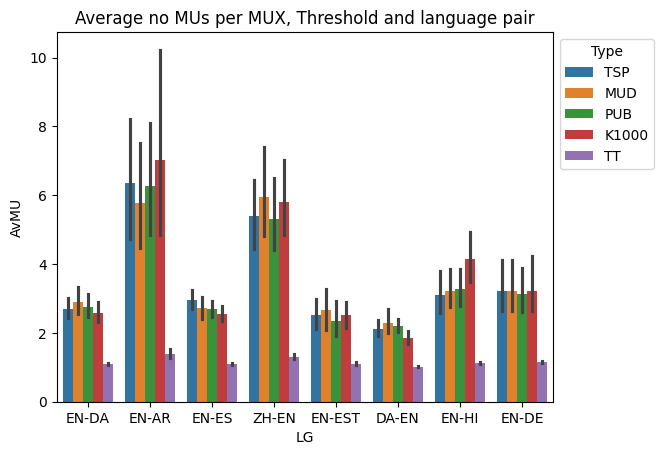

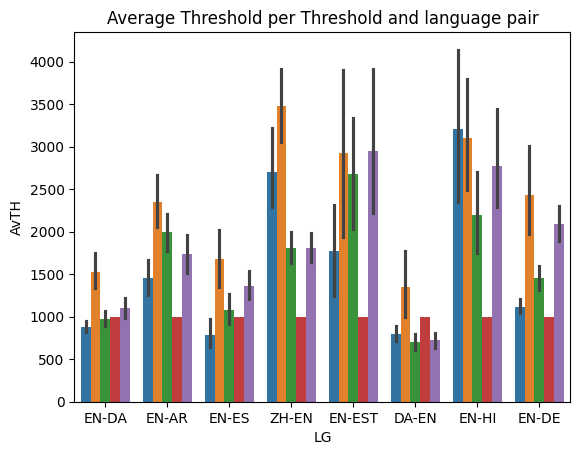

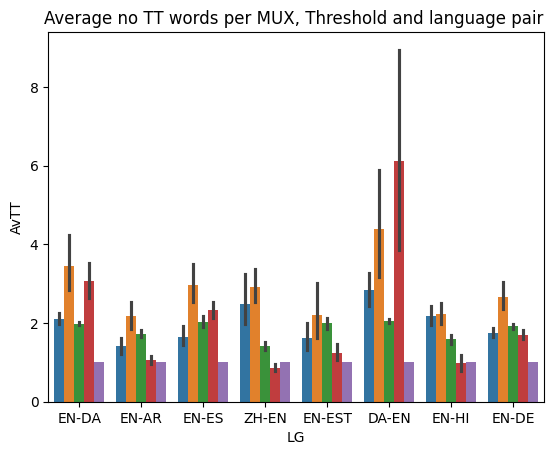

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt  


# Average MUs per MUX
ax = sns.barplot(x='LG', y='AvMU', hue='Type', data=N)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Average no MUs per MUX, Threshold and language pair')
plt.show()

# Average MUs per MUX
ax = sns.barplot(x='LG', y='AvTH', hue='Type', data=N)
ax.get_legend().set_visible(False)
ax.set_title('Average Threshold per Threshold and language pair')
plt.show()

# Average TT words per MUX
ax = sns.barplot(x='LG', y='AvTT', hue='Type', data=N)
ax.get_legend().set_visible(False)
ax.set_title('Average no TT words per MUX, Threshold and language pair ')
plt.show()

#groups = N.groupby('LG')
#for g, group in groups:
#    print(g, group.AvMU)


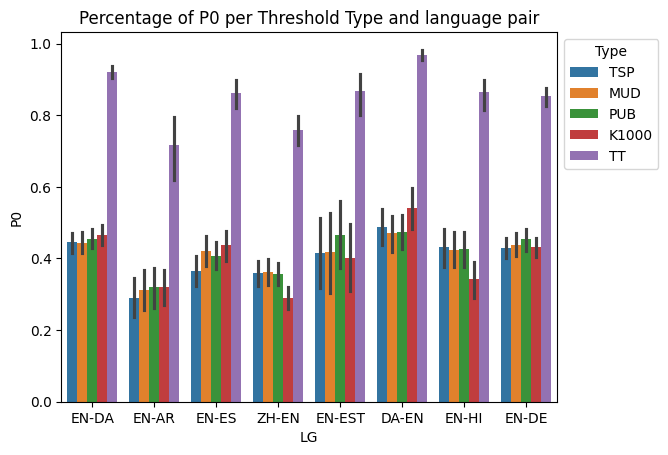

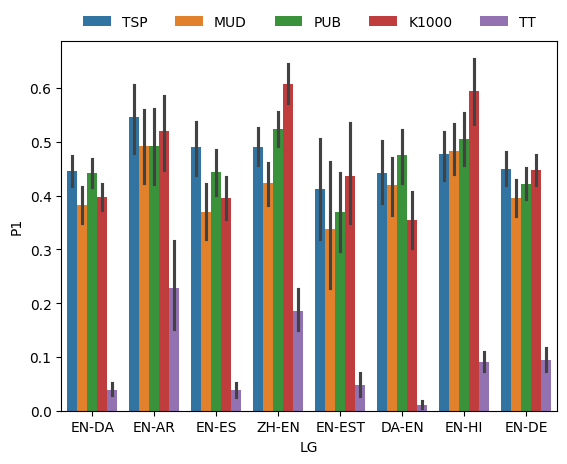

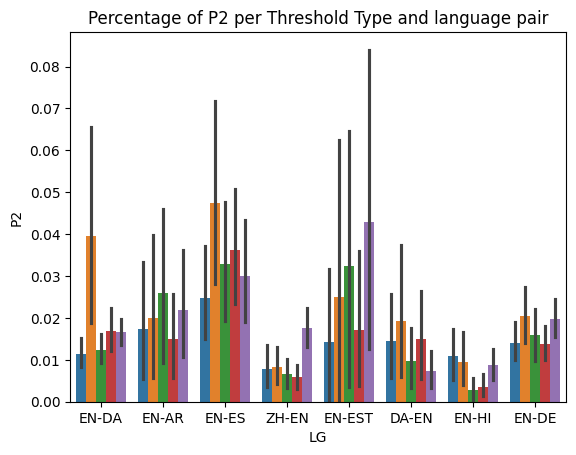

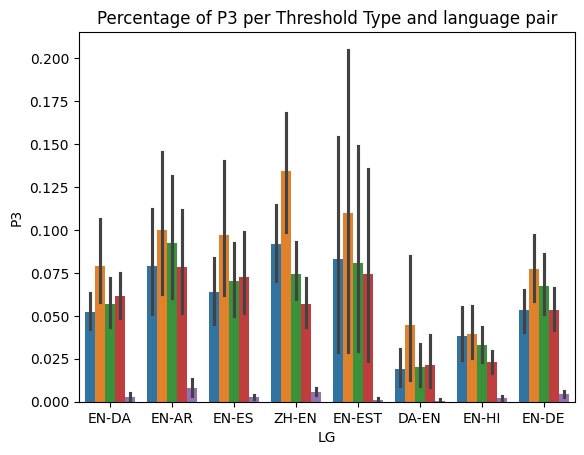

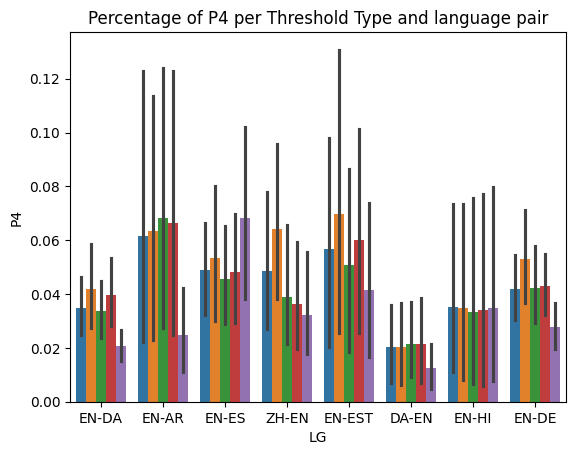

In [27]:
# Scatter plot with hue
import matplotlib.pyplot as plt  

ax = sns.barplot(x='LG', y='P0', hue='Type', data=N)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Percentage of P0 per Threshold Type and language pair')
plt.show()

ax = sns.barplot(x='LG', y='P1', hue='Type', data=N)
#ax.get_legend().set_visible(False)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False,
)
#ax.set_title('Percentage of P1 per Threshold Type and language pair')
plt.show()

ax = sns.barplot(x='LG', y='P2', hue='Type', data=N)
ax.get_legend().set_visible(False)
ax.set_title('Percentage of P2 per Threshold Type and language pair')
plt.show()

ax = sns.barplot(x='LG', y='P3', hue='Type', data=N)
ax.set_title('Percentage of P3 per Threshold Type and language pair')
ax.get_legend().set_visible(False)
plt.show()

ax = sns.barplot(x='LG', y='P4', hue='Type', data=N)
ax.set_title('Percentage of P4 per Threshold Type and language pair')
ax.get_legend().set_visible(False)


## Average words per MX, MUs per MX

In [35]:
TTdf = N.pivot(index='n', values='AvTT', columns='Type')
MUdf = N.pivot(index='n', values='AvMU', columns='Type')

print("Average words per MX, MUs per MX")

Stype = ['K1000', 'MUD', 'PUB', 'TSP', 'TT']
for s in Stype:
    print(f"{s}\t{np.mean(TTdf[s]):4.2f} \t {np.mean(MUdf[s]):4.2f} ")
#    print(f"{s} {np.mean(P0df[s] + P1df[s])}")


Average words per MX, MUs per MX
K1000	2.20 	 3.70 
MUD	3.00 	 3.70 
PUB	1.82 	 3.55 
TSP	2.06 	 3.59 
TT	1.00 	 1.17 


## Correlations

In [20]:
P0df = N.pivot(index='n', values='P0', columns='Type')
P1df = N.pivot(index='n', values='P1', columns='Type')
P2df = N.pivot(index='n', values='P2', columns='Type')
P3df = N.pivot(index='n', values='P3', columns='Type')
P4df = N.pivot(index='n', values='P4', columns='Type')
Avdf = N.pivot(index='n', values='AvMU', columns='Type')

#print("AAA", P0df.head(), "\n", P1df.head())

Stype = ['K1000', 'MUD', 'PUB', 'TSP', 'TT']
for s in Stype:
    print(f"{s} \
{100*np.mean(P0df[s]):4.2f} \
{100*np.mean(P1df[s]):4.2f} \
{100*np.mean(P2df[s]):4.2f} \
{100*np.mean(P3df[s]):4.2f} \
{100*np.mean(P4df[s]):4.2f} \
{100*np.mean(P0df[s] + P1df[s]):4.2f}")
#    print(f"{s} {np.mean(P0df[s] + P1df[s])}")

print(f"\nCorrelation P0\n{P0df.corr()}")
print(f"\nCorrelation P1\n{P1df.corr()}")
print(f"\nCorrelation P2\n{P2df.corr()}")
print(f"\nCorrelation P3\n{P3df.corr()}")
print(f"\nCorrelation P4\n{P4df.corr()}")
print(f"\nCorrelation AX\n{Avdf.corr()}")


K1000 40.71 46.78 1.49 5.61 4.14 87.49
MUD 41.51 40.99 2.52 8.73 4.95 82.50
PUB 42.05 46.28 1.48 6.22 3.97 88.33
TSP 40.75 46.82 1.34 6.01 4.19 87.56
TT 85.42 9.30 1.86 0.38 3.04 94.72

Correlation P0
Type      K1000       MUD       PUB       TSP        TT
Type                                                   
K1000  1.000000  0.703106  0.799318  0.765221  0.408765
MUD    0.703106  1.000000  0.796895  0.762539  0.357203
PUB    0.799318  0.796895  1.000000  0.869510  0.395125
TSP    0.765221  0.762539  0.869510  1.000000  0.375312
TT     0.408765  0.357203  0.395125  0.375312  1.000000

Correlation P1
Type      K1000       MUD       PUB       TSP        TT
Type                                                   
K1000  1.000000  0.579650  0.750885  0.675544  0.278963
MUD    0.579650  1.000000  0.705123  0.653178  0.107731
PUB    0.750885  0.705123  1.000000  0.829959  0.133133
TSP    0.675544  0.653178  0.829959  1.000000  0.148162
TT     0.278963  0.107731  0.133133  0.148162  1.000000

## More visualization

/home/jupyterlab/JupyterLab/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/jupyterlab/JupyterLab/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/jupyterlab/JupyterLab/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/jupyterlab/JupyterLab/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


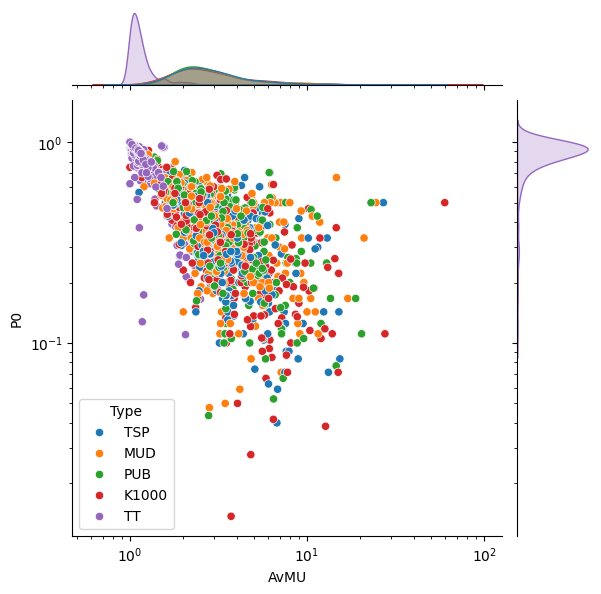

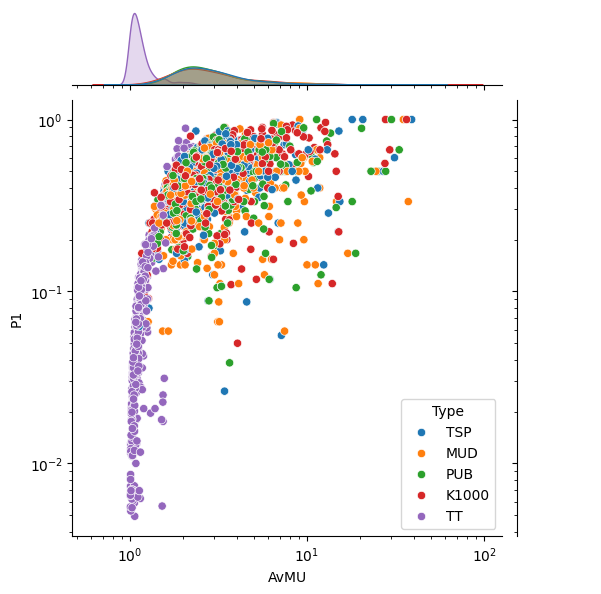

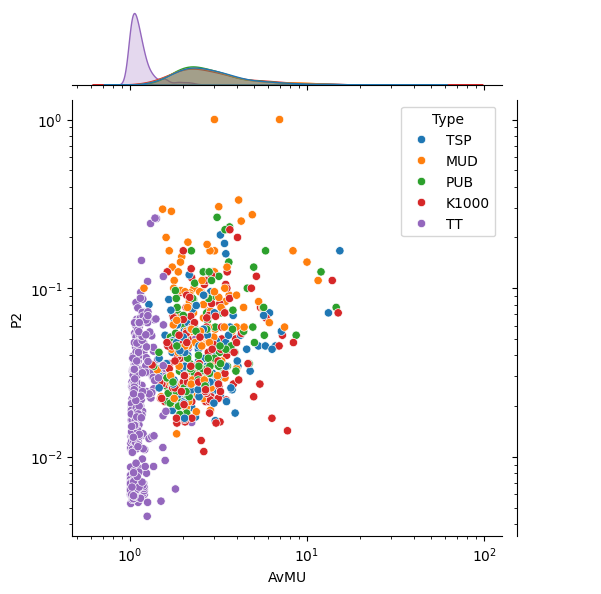

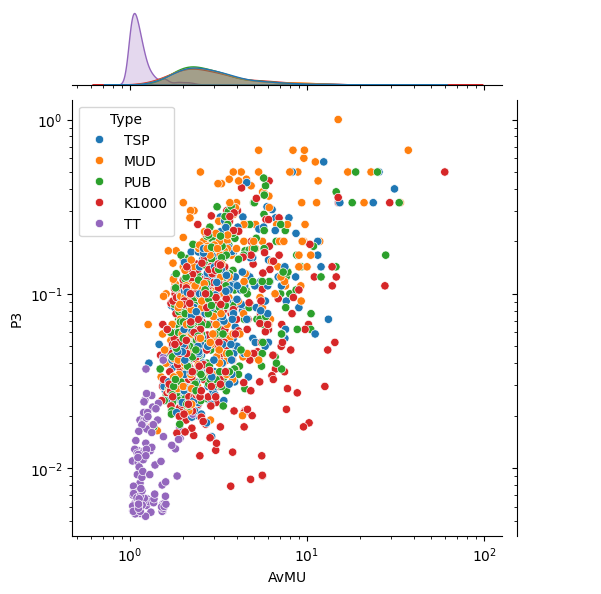

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt  

#sns.displot(N[['P0', 'P1', 'P2','P3','P4']], kind="kde", col='Study')
M= N[['P0', 'P1', 'P2', 'P3','P4', 'Type', 'LG']]

sns.jointplot(N, y='P0', x='AvMU', hue='Type', marginal_kws={'log_scale': True})
sns.jointplot(N, y='P1', x='AvMU', hue='Type', marginal_kws={'log_scale': True})
sns.jointplot(N, y='P2', x='AvMU', hue='Type', marginal_kws={'log_scale': True})
sns.jointplot(N, y='P3', x='AvMU', hue='Type', marginal_kws={'log_scale': True})
#sns.displot(M, x='P1', hue='Type', kind='kde', col='LG')
#sns.displot(M, x='P2', hue='Type', kind='kde', col='LG')
#sns.displot(M, x='P3', hue='Type', kind='kde', col='LG')
#sns.displot(M, x='P4', hue='Type', kind='kde', col='LG')

#sns.displot(M[N.Type == 'TSP'], kind='ecdf')
#sns.displot(N[N.Type == 'PUB'], kind='ecdf')
#sns.displot(N[N.Type == 'K1000'],kind='ecdf')


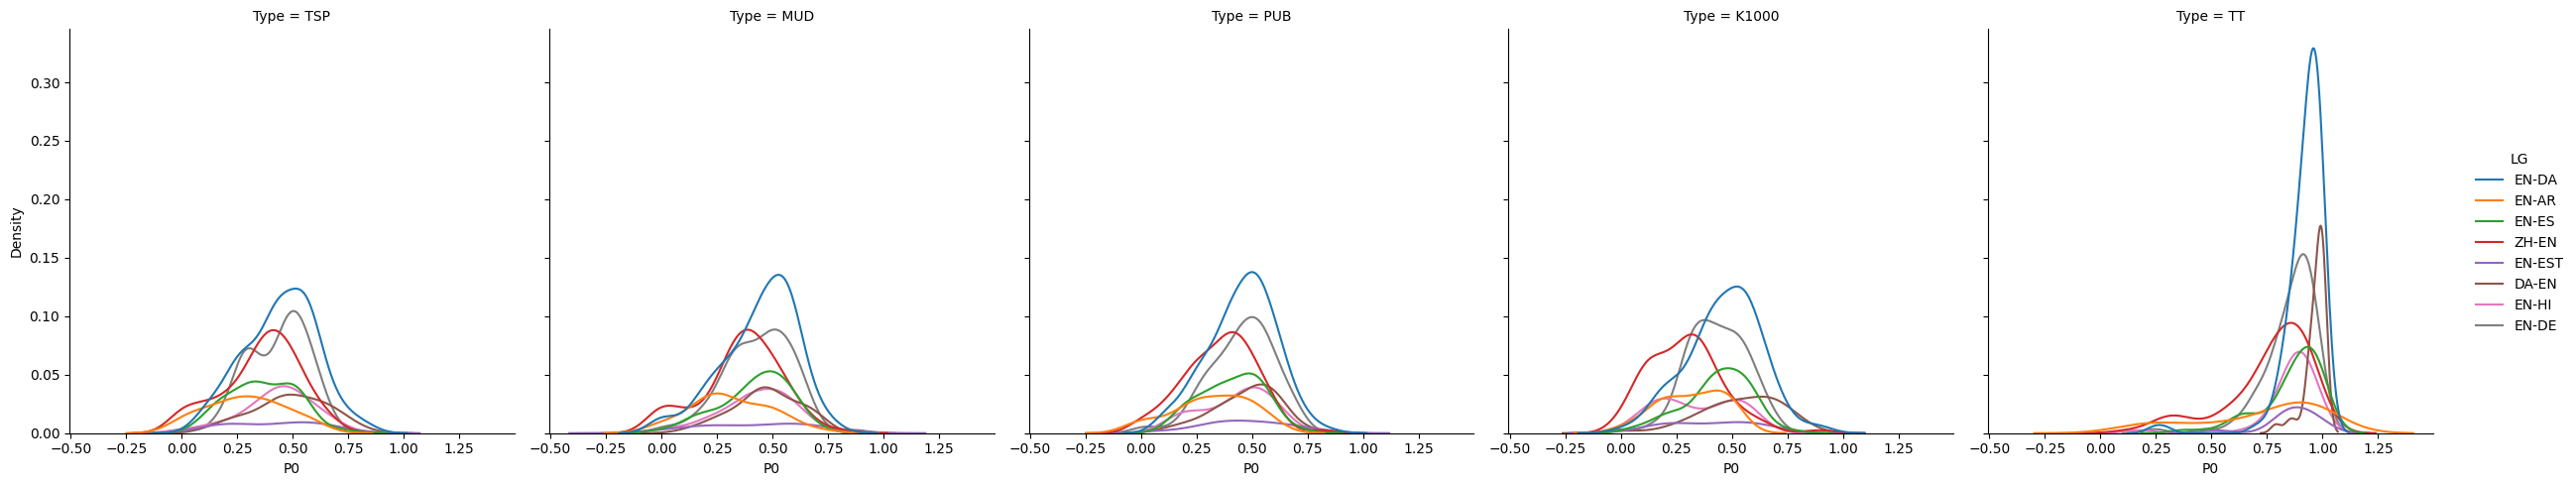

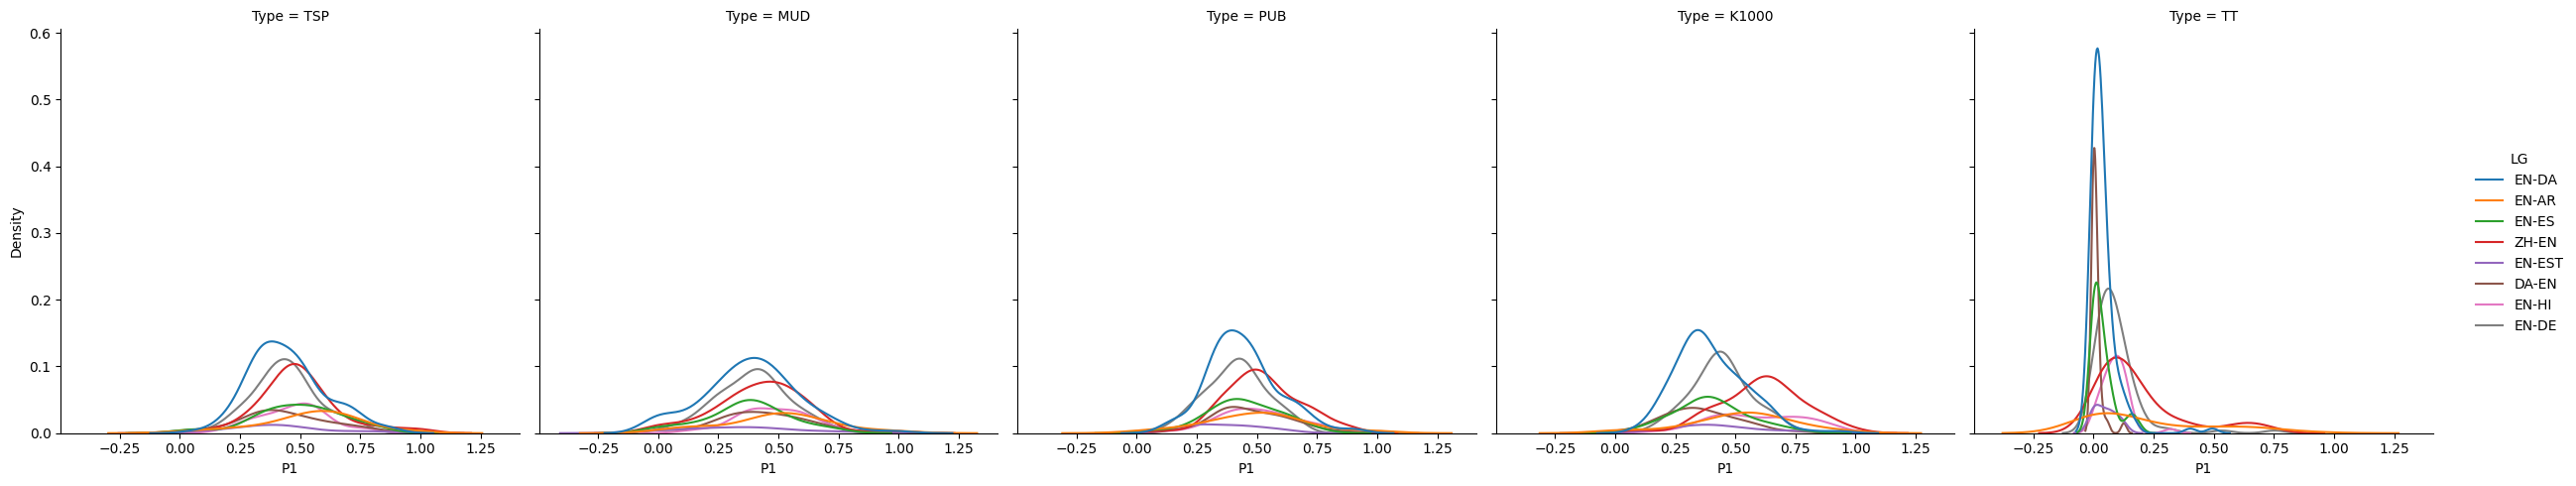

In [209]:
import seaborn as sns

M= N[['P0', 'P1', 'P2', 'P3','P4', 'Type', 'LG']]
M = N[['P0', 'P1', 'Type', 'LG']]

sns.displot(M, x='P0', col='Type', kind='kde', hue='LG')
sns.displot(M, x='P1', col='Type', kind='kde', hue='LG')
#sns.displot(M, x='P2', hue='Type', kind='kde', col='LG')
#sns.displot(M, x='P3', hue='Type', kind='kde', col='LG')
#sns.displot(M, x='P4', hue='Type', kind='kde', col='LG')

#sns.displot(M[N.Type == 'TSP'], kind='ecdf')
#sns.displot(N[N.Type == 'PUB'], kind='ecdf')
#sns.displot(N[N.Type == 'K1000'],kind='ecdf')


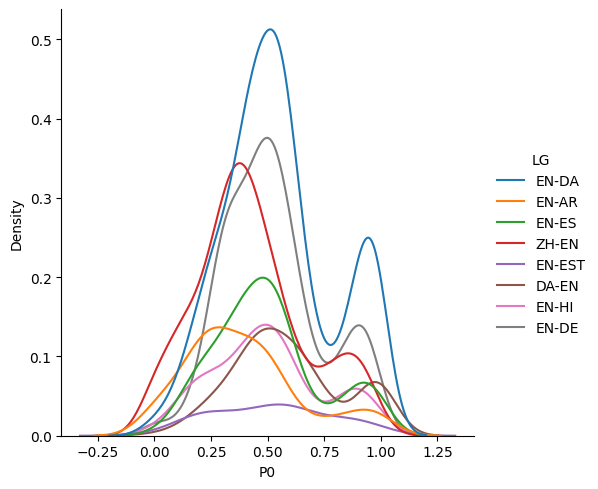

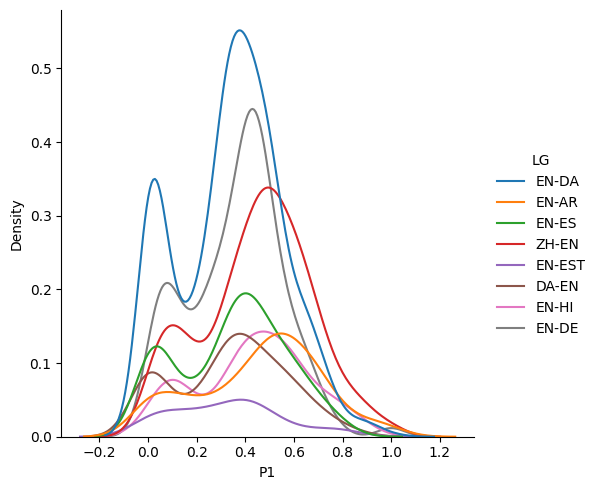

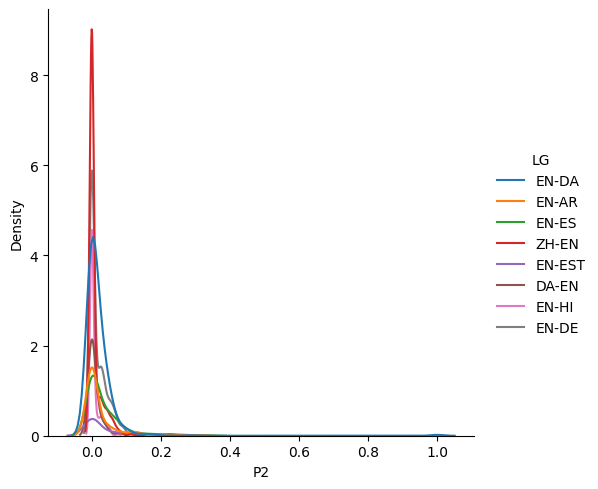

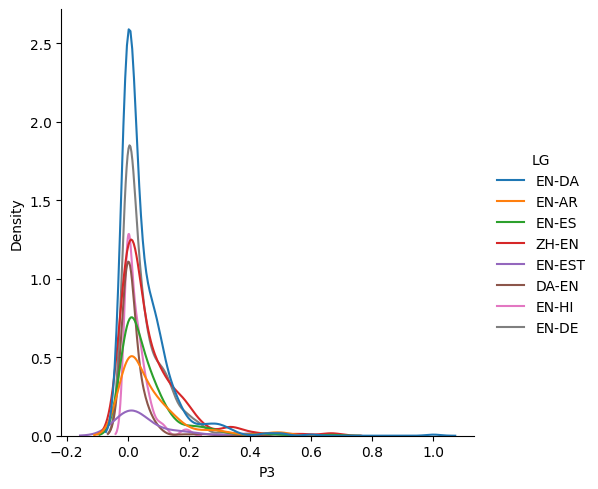

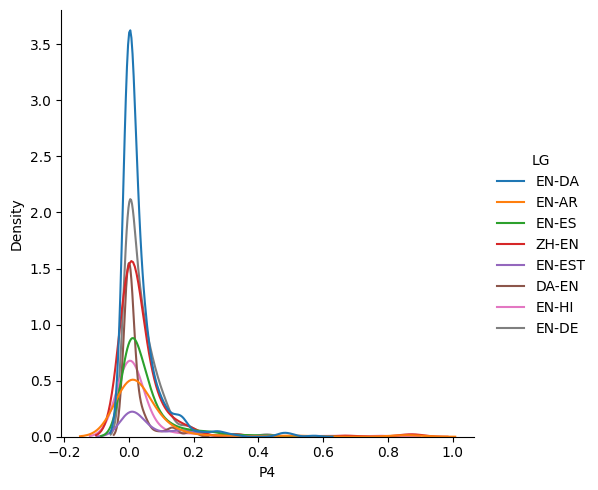

In [206]:
import seaborn as sns

#sns.displot(N[['P0', 'P1', 'P2','P3','P4']], kind="kde", col='Study')
M= N[['P0', 'P1', 'P2', 'P3','P4', 'LG']]

sns.displot(M, x='P0', hue='LG', kind='kde')
sns.displot(M, x='P1', hue='LG', kind='kde')
sns.displot(M, x='P2', hue='LG', kind='kde')
sns.displot(M, x='P3', hue='LG', kind='kde')
sns.displot(M, x='P4', hue='LG', kind='kde')

#sns.displot(M[N.Type == 'TSP'], kind='ecdf')
#sns.displot(N[N.Type == 'PUB'], kind='ecdf')
#sns.displot(N[N.Type == 'K1000'],kind='ecdf')


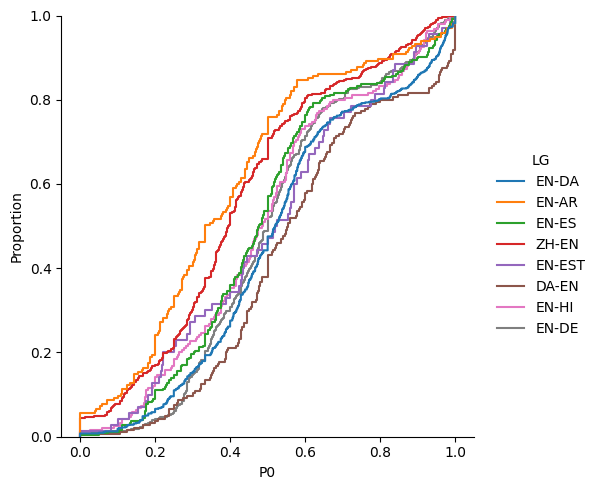

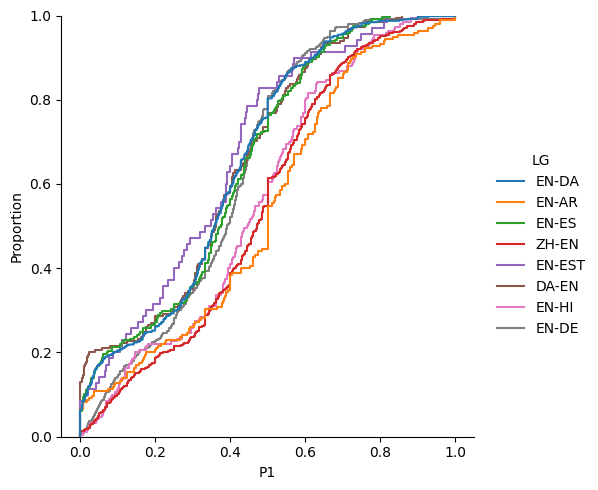

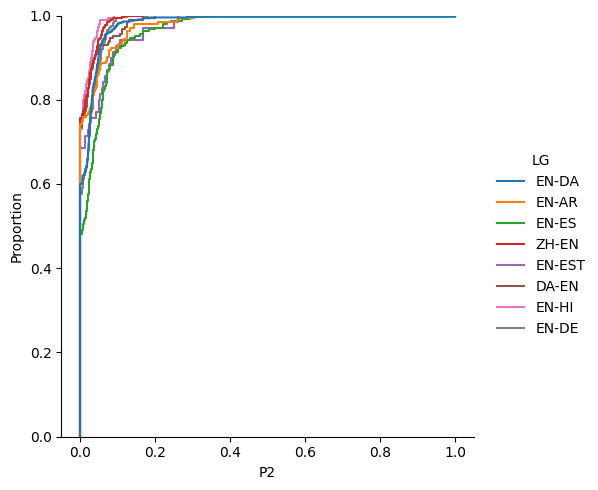

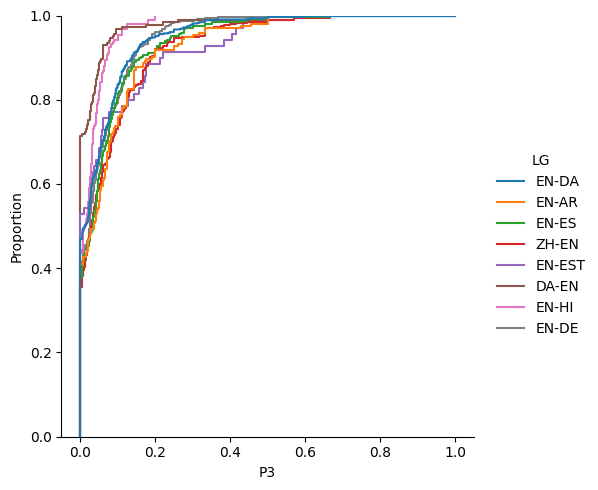

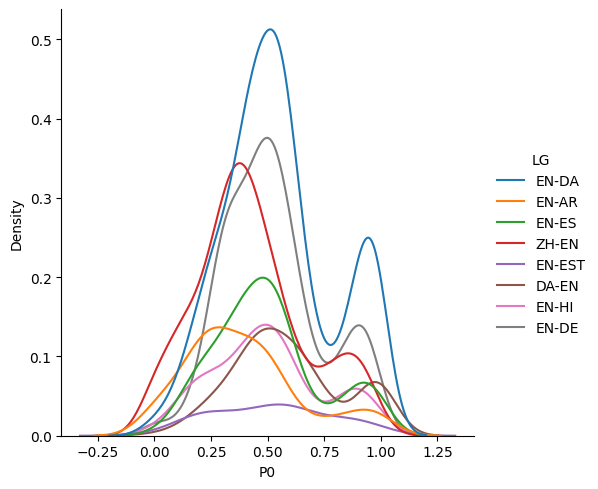

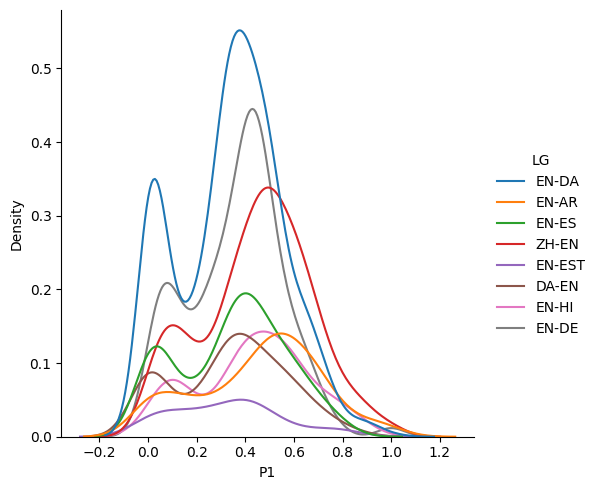

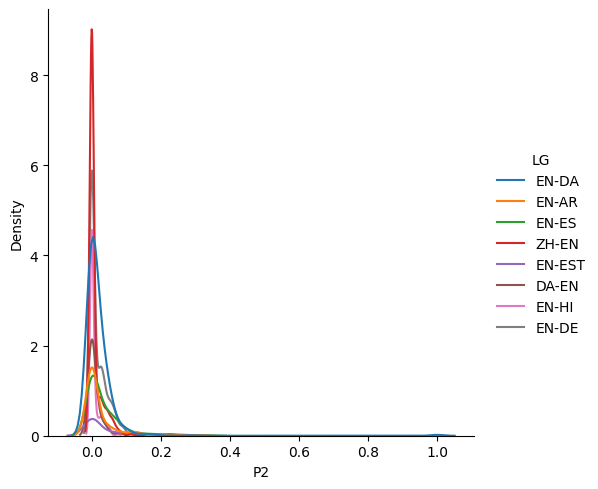

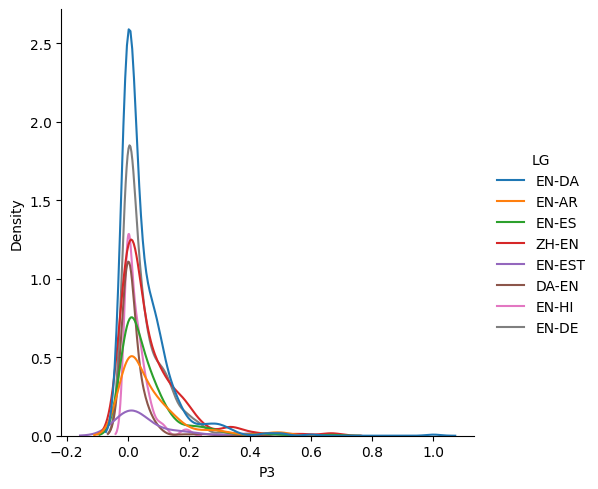

In [207]:
import seaborn as sns

#sns.displot(N[['P0', 'P1', 'P2','P3','P4']], kind="kde", col='Study')
sns.displot(N, x='P0', kind='ecdf', hue='LG')
sns.displot(N, x='P1', kind='ecdf', hue='LG')
sns.displot(N, x='P2', kind='ecdf', hue='LG')
sns.displot(N, x='P3', kind='ecdf', hue='LG')

sns.displot(N, x='P0', kind='kde', hue='LG')
sns.displot(N, x='P1', kind='kde', hue='LG')
sns.displot(N, x='P2', kind='kde', hue='LG')
sns.displot(N, x='P3', kind='kde', hue='LG')
